# Task 3: Correlation Between News Sentiment and Stock Movement

This notebook aligns news to trading days, scores sentiment, computes returns, and measures Pearson correlation.

In [10]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sys.path.append(str(Path.cwd().parent))

from src.data_loader import load_news_data, load_stock_prices
from src.sentiment import daily_average_sentiment, daily_returns, pearson_correlation, score_headlines

sns.set_theme(style='whitegrid')
NEWS_PATH = Path('../data/raw/financial_news.csv')
STOCK_PATH = Path('../data/raw/stock_prices.csv')
print('News exists:', NEWS_PATH.exists())
print('Stock exists:', STOCK_PATH.exists())

News exists: True
Stock exists: True


In [2]:
news = load_news_data(str(NEWS_PATH))
prices = load_stock_prices(str(STOCK_PATH))

print('News rows:', len(news))
print('Price rows:', len(prices))
print('Stocks in news:', news['stock'].nunique())
print('Stocks in prices:', prices['stock'].nunique())

✓ Loaded 1407328 articles
✓ Date range: 2011-04-27 21:01:48-04:00 to 2020-06-11 17:12:35-04:00
✓ Unique publishers: 1034
✓ Unique stocks: 6204
✓ Loaded 18019 trading days
✓ Date range: 2009-01-02 00:00:00 to 2023-12-29 00:00:00
✓ Price range: $0.17 to $379.84
News rows: 1407328
Price rows: 18019
Stocks in news: 6204
Stocks in prices: 5


In [6]:
# Keep overlapping stocks only
common_stocks = sorted(set(news['stock']).intersection(set(prices['stock'])))
print('Common stocks count:', len(common_stocks), common_stocks)

news = news[news['stock'].isin(common_stocks)].copy()
prices = prices[prices['stock'].isin(common_stocks)].copy()

# Reduce to date granularity for matching and make timestamps timezone-consistent
news['date'] = pd.to_datetime(news['date'], errors='coerce')
news = news.dropna(subset=['date'])
news['news_day'] = news['date'].dt.tz_localize(None).dt.floor('D')
prices['date'] = pd.to_datetime(prices['date'], errors='coerce').dt.floor('D')

# Build trading calendar per stock and align each news item to next trading day
cal = prices[['stock', 'date']].drop_duplicates().sort_values(['stock', 'date'])
aligned_parts = []
for s in common_stocks:
    n = news[news['stock'] == s].sort_values('news_day')
    c = cal[cal['stock'] == s].sort_values('date')
    if n.empty or c.empty:
        continue
    m = pd.merge_asof(
        n,
        c[['date']].rename(columns={'date': 'trade_day'}),
        left_on='news_day',
        right_on='trade_day',
        direction='forward'
    )
    m['stock'] = s
    m['date'] = m['trade_day']
    aligned_parts.append(m)

aligned_news = pd.concat(aligned_parts, ignore_index=True) if aligned_parts else pd.DataFrame()
print('Aligned news rows:', len(aligned_news))

Common stocks count: 4 ['AAPL', 'AMZN', 'GOOG', 'NVDA']
Aligned news rows: 40


In [7]:
# Sentiment scoring
scored = score_headlines(aligned_news, headline_col='headline', method='textblob')
daily_sent = daily_average_sentiment(scored[['stock', 'date', 'sentiment']], date_col='date', stock_col='stock')

# Daily returns (use close because merged yfinance file does not include adj_close)
daily_ret = daily_returns(prices[['stock', 'date', 'close']].copy(), date_col='date', price_col='close')

corr = pearson_correlation(daily_sent, daily_ret)
print(f'Pearson correlation (sentiment vs daily return): {corr:.4f}')

merged = pd.merge(daily_sent, daily_ret, on=['stock', 'date'], how='inner')
print('Merged daily rows for correlation:', len(merged))
merged.head()

Pearson correlation (sentiment vs daily return): 0.2227
Merged daily rows for correlation: 14


,stock,date,sentiment,return
0,AAPL,2020-06-09,0.088333,3.157792
1,AAPL,2020-06-10,0.166919,2.572771
2,AMZN,2020-06-09,-0.020833,3.042714
3,AMZN,2020-06-10,0.204798,1.791329
4,GOOG,2020-06-04,0.000000,-1.684800


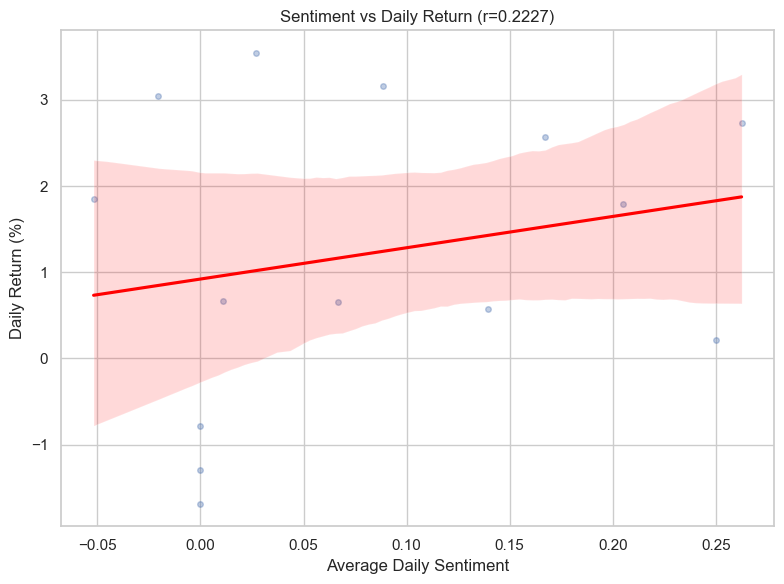

In [8]:
# Scatter plot with regression line
plt.figure(figsize=(8, 6))
sns.regplot(data=merged, x='sentiment', y='return', scatter_kws={'alpha': 0.35, 's': 16}, line_kws={'color': 'red'})
plt.title(f'Sentiment vs Daily Return (r={corr:.4f})')
plt.xlabel('Average Daily Sentiment')
plt.ylabel('Daily Return (%)')
plt.tight_layout()
plt.show()

sentiment_category
negative    1.855992
neutral     0.583290
positive    1.672328
Name: return, dtype: float64


C:\Users\gebaw\AppData\Local\Temp\ipykernel_10260\2407516201.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cat_ret.index, y=cat_ret.values, palette=['#d62728', '#7f7f7f', '#2ca02c'])


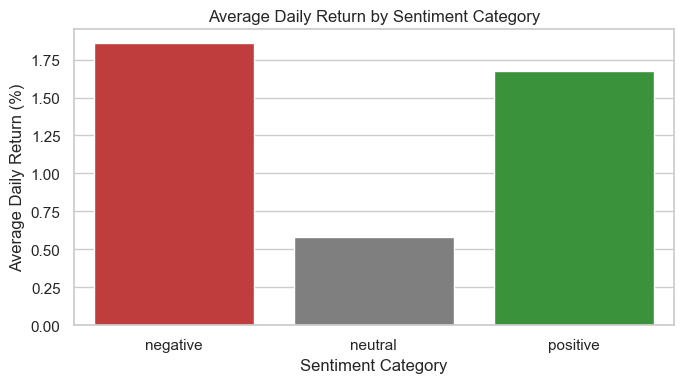

In [9]:
# Classify days by sentiment category and compare average returns
def sentiment_label(x):
    if x > 0.05:
        return 'positive'
    if x < -0.05:
        return 'negative'
    return 'neutral'

merged['sentiment_category'] = merged['sentiment'].apply(sentiment_label)
cat_ret = merged.groupby('sentiment_category')['return'].mean().reindex(['negative', 'neutral', 'positive'])
print(cat_ret)

plt.figure(figsize=(7, 4))
sns.barplot(x=cat_ret.index, y=cat_ret.values, palette=['#d62728', '#7f7f7f', '#2ca02c'])
plt.title('Average Daily Return by Sentiment Category')
plt.xlabel('Sentiment Category')
plt.ylabel('Average Daily Return (%)')
plt.tight_layout()
plt.show()

## Interpretation
- Pearson $r$ quantifies linear association between average daily sentiment and daily return.
- A weak $|r|$ suggests sentiment alone is insufficient for prediction; combine with technical and macro factors.
- This is correlation, not causation, and may miss lagged or event-specific impacts.